In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

In [3]:
stock_symbol = "AAPL"

data = yf.download(
    stock_symbol,
    start="2022-01-01",
    end="2023-01-01",
    progress=False
)

data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939743,178.790298,173.735915,173.853227,104487900
2022-01-04,175.681366,178.848915,175.114335,178.545850,99310400
2022-01-05,171.008301,176.140896,170.734564,175.593422,94537600
2022-01-06,168.153564,171.379770,167.801615,168.837907,96904000
2022-01-07,168.319763,170.245709,167.205258,169.023663,86709100


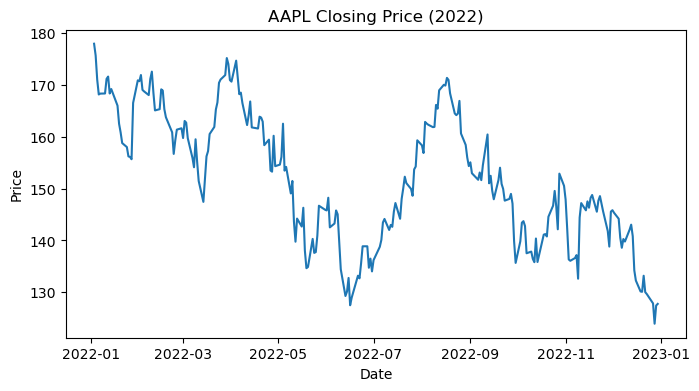

In [5]:
plt.figure(figsize=(8,4))
plt.plot(data['Close'])
plt.title("AAPL Closing Price (2022)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


In [7]:
data['Lag1'] = data['Close'].shift(1)
data['Lag2'] = data['Close'].shift(2)

data.dropna(inplace=True)

X = data[['Lag1', 'Lag2']]
y = data['Close']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)


In [11]:
model = XGBRegressor(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

In [13]:
predictions = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
rmse

4.088269207733568

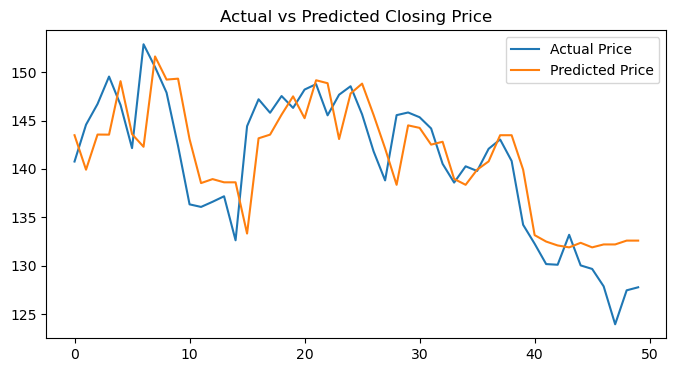

In [15]:
plt.figure(figsize=(8,4))
plt.plot(y_test.values, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.title("Actual vs Predicted Closing Price")
plt.legend()
plt.show()

In [17]:
actual_direction = np.sign(y_test.values[1:] - y_test.values[:-1])
pred_direction = np.sign(predictions[1:] - predictions[:-1])

directional_accuracy = np.mean(actual_direction == pred_direction)
directional_accuracy

0.46647230320699706